In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from stochastique.models.FHN import model_FHN, equilibria_FHN
from stochastique.analysis.simulation import simulate_trajectory, simulate_stochastic_cloud

In [2]:
N_STEPS_DEFAULT = 1000

# 1. Проведем сравнение стохастических решений для $a = 1.1$, $a = 1.01$

(а) Построим графики $x(\varepsilon)$, пропустив переходный процесс $T = 100$.

In [3]:
from stochastique.analysis.excitement import localize_stochastic_excitement

Run multiple simulations: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]
/tmp/ipykernel_62608/1045397707.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Run multiple simulations: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


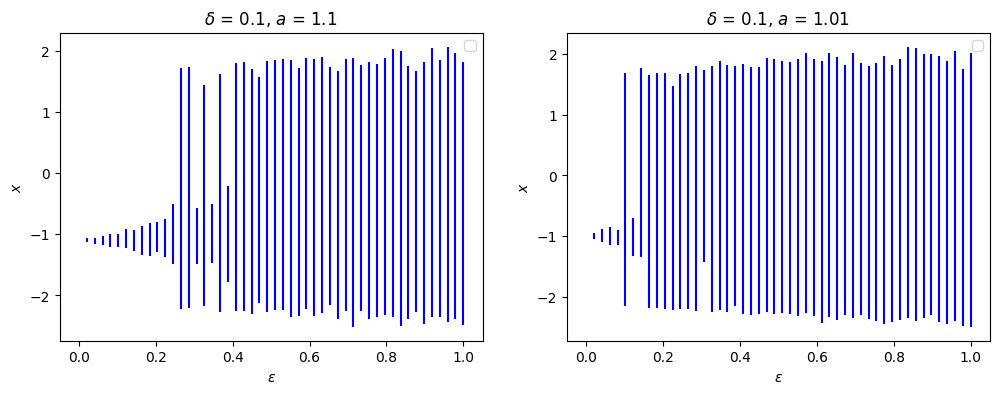

In [4]:
rng = np.random.default_rng()

delta, a = 0.1, None
a_values = [1.1, 1.01]

time_span = np.linspace(0, 10, num=10 ** 3)
noise_mask = np.array([1, 0])   # add noise to 1st equation only
eps_values = np.linspace(0, 1, num=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for a, ax in zip(a_values, axes):
    params = dict(delta=delta, a=a)
    state_init = equilibria_FHN(**params)[0]

    localize_stochastic_excitement(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        noise_mask=noise_mask,
        eps_values=eps_values,
        num_simulations=1,
        rng=rng,
        ax=ax,
        highlight=False,
    )

    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a}')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel(r'$x$')
    ax.legend()

Локализуем $\varepsilon$ зоны стохастического возбуждения.

In [5]:
from stochastique.analysis.excitement import localize_stochastic_excitement

Run multiple simulations: 100%|██████████| 10/10 [00:11<00:00,  1.18s/it]


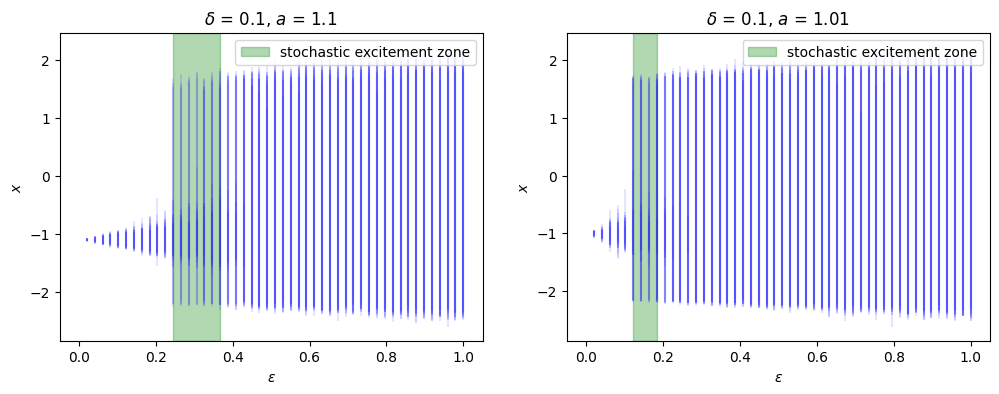

In [6]:
rng = np.random.default_rng()

delta, a = 0.1, None
a_values = [1.1, 1.01]

time_span = np.linspace(0, 10, num=10 ** 3)
noise_mask = np.array([1, 0])   # add noise to 1st equation only
eps_values = np.linspace(0, 1, num=50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for a, ax in zip(a_values, axes):
    params = dict(delta=delta, a=a)
    state_init = equilibria_FHN(**params)[0]

    localize_stochastic_excitement(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        noise_mask=noise_mask,
        eps_values=eps_values,
        num_simulations=10,
        rng=rng,
        ax=ax,
    )

    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a}')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_ylabel(r'$x$')
    ax.legend()

(б) Построим временные ряды при различных значениях $\varepsilon$: с возбуждением и без возбуждения.

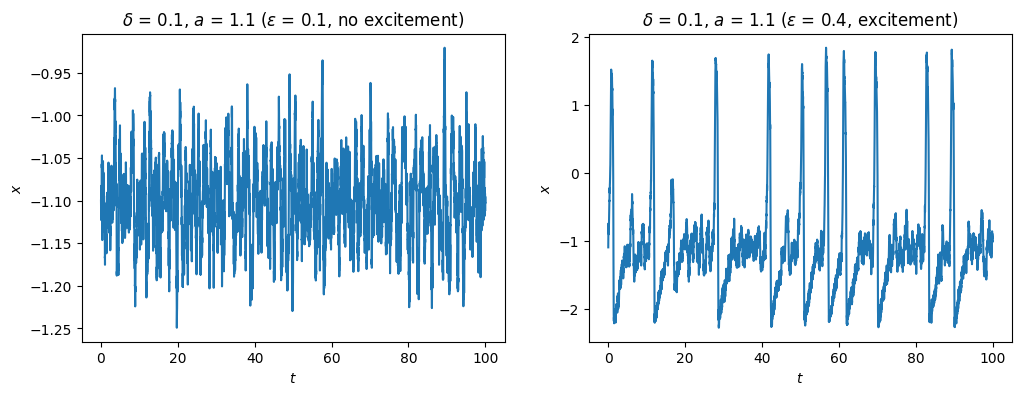

In [7]:
rng = np.random.default_rng()

delta, a = 0.1, 1.1
eps_values = [
    (0.1, 'no excitement'),
    (0.4, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    params = dict(delta=delta, a=a)

    state_init = equilibria_FHN(**params)[0]
    trajectory = simulate_trajectory(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        rng=rng,
    )
    # trajectory = trajectory[100:]   # clip transient
    trajectory_x = trajectory[:, 0]
    
    ax.plot(time_span, trajectory_x)
    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a} ($\varepsilon$ = {eps}, {comment})')
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$x$')

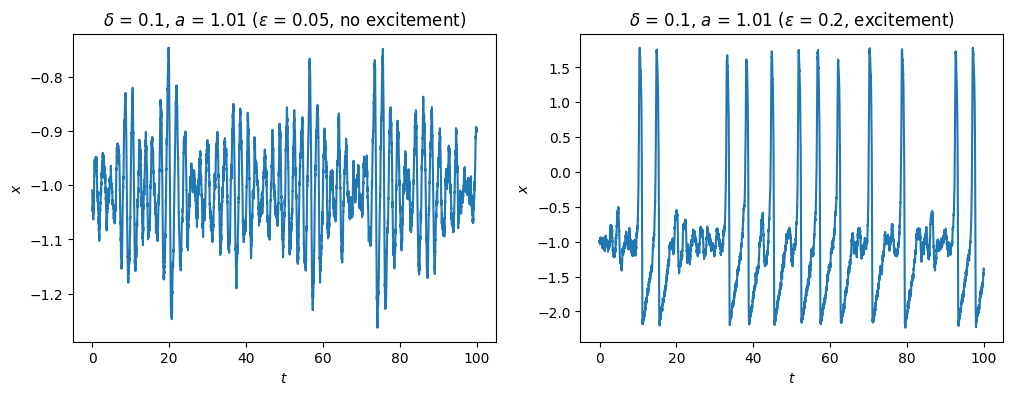

In [8]:
rng = np.random.default_rng()

delta, a = 0.1, 1.01
eps_values = [
    (0.05, 'no excitement'),
    (0.2, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    params = dict(delta=delta, a=a)

    state_init = equilibria_FHN(**params)[0]
    trajectory = simulate_trajectory(
        model_func=model_FHN,
        params=params,
        state_init=state_init,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        rng=rng,
    )
    # trajectory = trajectory[100:]   # clip transient
    trajectory_x = trajectory[:, 0]
    
    ax.plot(time_span, trajectory_x)
    ax.set_title(rf'$\delta$ = {delta}, $a$ = {a} ($\varepsilon$ = {eps}, {comment})')
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$x$')

# 2. Построим доверительные эллипсы в допороговой и надпороговой зонах для $a = 1.1$, $a = 1.01$

In [9]:
from stochastique.core.numerical import stochastic_sensitivity_matrix_2d
from stochastique.util.plot import plot_confidence_ellipse_2d

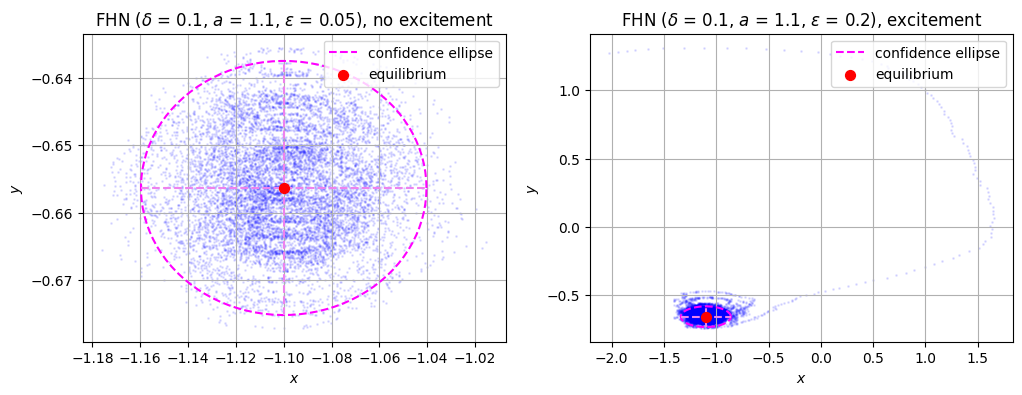

In [10]:
delta, a = 0.1, 1.1
eps_values = [
    (0.05, 'no excitement'),
    (0.2, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

# eps, comment = eps_values[0]
params = dict(delta=delta, a=a)
equilibrium = equilibria_FHN(**params)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    # trajectory = simulate_trajectory(
    #     model_func=model_FHN,
    #     params=params,
    #     state_init=equilibrium,
    #     time_span=time_span,
    #     epsilon=eps,
    #     noise_mask=noise_mask,
    #     rng=rng,
    # )

    W = stochastic_sensitivity_matrix_2d(
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium,
        noise_mask=noise_mask,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium,
        W=W,
        epsilon=eps,
        major_axes=True,
    )

    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=params,
        state_init=equilibrium,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        num_simulations=1,
    )
    ax.set_title(rf'FHN ($\delta$ = {delta}, $a$ = {a}, $\varepsilon$ = {eps}), {comment}')

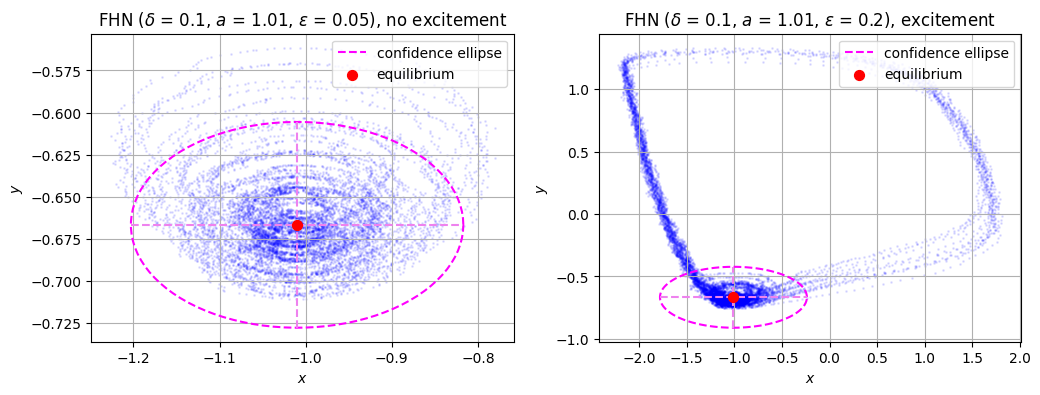

In [11]:
delta, a = 0.1, 1.01
eps_values = [
    (0.05, 'no excitement'),
    (0.2, 'excitement')
]

time_span = np.linspace(0, 100, num=10 ** 4)
noise_mask = np.array([1, 0])   # add noise to 1st equation only

# eps, comment = eps_values[0]
params = dict(delta=delta, a=a)
equilibrium = equilibria_FHN(**params)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for eps_state, ax in zip(eps_values, axes):
    eps, comment = eps_state
    # trajectory = simulate_trajectory(
    #     model_func=model_FHN,
    #     params=params,
    #     state_init=equilibrium,
    #     time_span=time_span,
    #     epsilon=eps,
    #     noise_mask=noise_mask,
    #     rng=rng,
    # )

    W = stochastic_sensitivity_matrix_2d(
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium,
        noise_mask=noise_mask,
    )

    plot_confidence_ellipse_2d(
        ax=ax,
        equilibrium=equilibrium,
        W=W,
        epsilon=eps,
        major_axes=True,
    )

    # ax.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.3, label='trajectory')

    simulate_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=params,
        state_init=equilibrium,
        time_span=time_span,
        epsilon=eps,
        noise_mask=noise_mask,
        num_simulations=1,
    )
    ax.set_title(rf'FHN ($\delta$ = {delta}, $a$ = {a}, $\varepsilon$ = {eps}), {comment}')